#BASIC STATS


In [1]:
import numpy as np 
import pandas as pd

In [3]:
def mean_avg(x):
    sum  =0
    for i in range(len(x)):
        sum += x[i]

    return sum/len(x)

In [4]:
def variance(x):

    sum = 0 
    m = mean_avg(x)
    for i in range(len(x)):
        sum+=(x[i]-m)**2

    return sum/len(x)

In [5]:
def std_dev(x):
    return variance(x)**0.5

In [6]:
def z_score_norm(x):

    m = mean_avg(x)
    s = std_dev(x)

    for i in range(len(x)):
        x[i] = (x[i]-m)

    return x

In [7]:
def covariance(x,y):

    sum = 0
    x_m = mean_avg(x)
    y_m = mean_avg(y)

    for i in range(len(x)):
        sum += (x[i]-x_m)*(y[i]-y_m)

    return (sum)/(len(x)-1)

In [8]:
import numpy as np

data = np.array([12,15,18,20,25])

B = 10000
boot_means = []

for _ in range(B):

    sample = np.random.choice(
        data,
        size=len(data),
        replace=True
    )

    boot_means.append(np.mean(sample))

lower = np.percentile(boot_means, 2.5)
upper = np.percentile(boot_means, 97.5)

print("95% CI:", lower, upper)

95% CI: 14.4 22.0


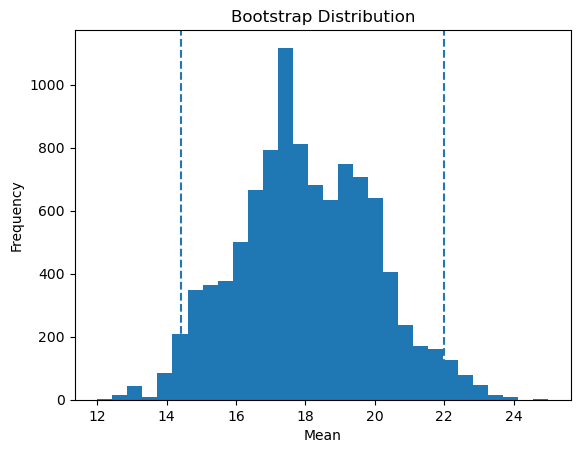

In [9]:
import matplotlib.pyplot as plt

plt.hist(boot_means, bins=30)

plt.axvline(lower, linestyle='--')
plt.axvline(upper, linestyle='--')

plt.xlabel("Mean")
plt.ylabel("Frequency")
plt.title("Bootstrap Distribution")
plt.show()

NAIVE BIAS CLASSIFIER - SPAM DETECTION 

In [10]:
import pandas as pd

In [12]:
df = pd.read_csv("email_spam.csv")

In [13]:
df

,Email_Text,Label
0,Congratulations! You have won a free iPhone. C...,1
1,Exclusive offer! Get 80% discount on all produ...,1
2,Claim your lottery prize before it expires.,1
3,Win cash rewards instantly by registering now.,1
4,Limited time offer! Free vacation package awaits.,1
5,You have been selected for a special reward.,1
6,Earn money from home with this secret method.,1
7,Get a free gift card worth $500 today.,1
8,Urgent! Your account has won a bonus prize.,1
9,Click now to receive your free coupon.,1


In [15]:
spam = df.iloc[0:20,0]
spam

0     Congratulations! You have won a free iPhone. C...
1     Exclusive offer! Get 80% discount on all produ...
2           Claim your lottery prize before it expires.
3        Win cash rewards instantly by registering now.
4     Limited time offer! Free vacation package awaits.
5          You have been selected for a special reward.
6         Earn money from home with this secret method.
7                Get a free gift card worth $500 today.
8           Urgent! Your account has won a bonus prize.
9                Click now to receive your free coupon.
10      Lowest loan rates available. Apply immediately.
11             You are the lucky winner of our contest.
12    Double your income with this amazing opportunity.
13               Act fast! Exclusive deal ends tonight.
14                    Free entry into our jackpot draw.
15         Your package is waiting. Verify details now.
16                  Unlock premium services at no cost.
17               Win a brand new car by entering

In [16]:
real = df.iloc[20:50,0]
real 

20    Reminder: Project meeting scheduled at 10 AM t...
21      Please find the attached assignment submission.
22       Can we reschedule our discussion to next week?
23       Thank you for attending the seminar yesterday.
24       Let's meet in the conference room after lunch.
25             Here are the notes from today's lecture.
26    The report has been uploaded to the shared drive.
27     Please review the document and provide feedback.
28          Your order has been successfully delivered.
29      Team outing is planned for this Friday evening.
30               The exam timetable has been announced.
31             Can you send me the presentation slides?
32            The maintenance work will start tomorrow.
33            Please complete the survey by end of day.
34         The payment has been processed successfully.
35                         Thank you for your purchase.
36                The meeting minutes have been shared.
37              Your interview is scheduled for 

In [26]:
words = dict()
for line in spam:
    for word in line.split():
        if word not in words:
            words[word] = 1
        elif word in words:
            x = words[word]
            words[word] = x+1
            
            

In [27]:
words

{'Congratulations!': 1,
 'You': 3,
 'have': 2,
 'won': 2,
 'a': 5,
 'free': 3,
 'iPhone.': 1,
 'Click': 2,
 'here': 1,
 'to': 2,
 'claim': 1,
 'now.': 3,
 'Exclusive': 2,
 'offer!': 2,
 'Get': 3,
 '80%': 1,
 'discount': 1,
 'on': 1,
 'all': 1,
 'products': 1,
 'today.': 3,
 'Claim': 2,
 'your': 3,
 'lottery': 1,
 'prize': 1,
 'before': 1,
 'it': 1,
 'expires.': 1,
 'Win': 2,
 'cash': 1,
 'rewards': 1,
 'instantly': 1,
 'by': 2,
 'registering': 1,
 'Limited': 1,
 'time': 1,
 'Free': 2,
 'vacation': 1,
 'package': 2,
 'awaits.': 1,
 'been': 1,
 'selected': 1,
 'for': 2,
 'special': 1,
 'reward.': 2,
 'Earn': 1,
 'money': 1,
 'from': 1,
 'home': 1,
 'with': 3,
 'this': 3,
 'secret': 1,
 'method.': 1,
 'gift': 1,
 'card': 1,
 'worth': 1,
 '$500': 1,
 'Urgent!': 1,
 'Your': 2,
 'account': 1,
 'has': 1,
 'bonus': 1,
 'prize.': 1,
 'now': 1,
 'receive': 1,
 'coupon.': 1,
 'Lowest': 1,
 'loan': 1,
 'rates': 1,
 'available.': 1,
 'Apply': 1,
 'immediately.': 1,
 'are': 1,
 'the': 1,
 'lucky': 1

In [28]:
num_words = words.values()
num_words

dict_values([1, 3, 2, 2, 5, 3, 1, 2, 1, 2, 1, 3, 2, 2, 3, 1, 1, 1, 1, 1, 3, 2, 3, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 2, 1, 2, 1, 1, 1, 2, 1, 2, 1, 1, 1, 1, 3, 3, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [29]:
sum = 0
for i in num_words:
    sum += i

sum

149

In [65]:
import string
class naive_bias:

    def __init__(self,x):
        self.x = x

    def fit(self):
        spam = self.x.iloc[0:20,0]
        real = self.x.iloc[20:50,0]
        spam_words = dict()
        real_words = dict()
        for line in spam:
            clean = ""
            for char in line : 
                if char not in string.punctuation:
                    clean+=char.lower()
            for word in clean.split():
                if word not in spam_words:
                    spam_words[word] = 1
                elif word in spam_words:
                    x = spam_words[word]
                    spam_words[word] = x+1
        for line in real:
            clean = ""
            for char in line : 
                if char not in string.punctuation:
                    clean+=char.lower()
            for word in clean.split():
                if word not in real_words:
                    real_words[word] = 1
                elif word in real_words:
                    x = real_words[word]
                    real_words[word] = x+1

        print("P(real) : 30/50 \nP(spam) : 20/50")
        return real_words,spam_words
    
    def pred(self,y,spam_words,real_words):
        spam_prob = 20/50
        real_prob = 30/50
        clean = ""
        for char in y : 
                if char not in string.punctuation:
                    clean+=char.lower()
        for word in clean.split():

            if word not in spam_words:
                spam_words[word] = 0.5
                spam_prob *= spam_words[word]/len(spam_words)
            else:
                spam_prob *= spam_words[word]/len(spam_words)

            if word not in real_words:
                real_words[word] = 0.5
                real_prob *= real_words[word]/len(real_words)
            else : 
                real_prob *= real_words[word]/len(real_words)

        if spam_prob > real_prob : 
            print("Spam detected ! ")
        else :
            print("Real Email !")
        


In [66]:
df = pd.read_csv("email_spam.csv")
nb = naive_bias(df)
rw , sw = nb.fit()

P(real) : 30/50 
P(spam) : 20/50


In [70]:
det = "congratuations , you just won a free gift "
nb.pred(det,sw,rw)

Spam detected ! 
